<a href="https://colab.research.google.com/github/PadmaDeepak/ML-LAB/blob/main/1bm23cs222_Lab-8-AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Data

First, we'll load the `income.csv` dataset into a pandas DataFrame. Please ensure this file is available in your Colab environment.

In [10]:
import pandas as pd

try:
    df = pd.read_csv('income - income.csv')
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    display(df.head())
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print("Error: 'income - income.csv' not found. Please upload the correct file or correct the filename.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully. Displaying the first 5 rows:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_level
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   fnlwgt          48842 non-null  int64
 2   education_num   48842 non-null  int64
 3   capital_gain    48842 non-null  int64
 4   capital_loss    48842 non-null  int64
 5   hours_per_week  48842 non-null  int64
 6   income_level    48842 non-null  int64
dtypes: int64(7)
memory usage: 2.6 MB


### Prepare Data for AdaBoost Classifier

Before building the model, we need to separate the features (X) from the target variable (y). Assuming 'income' is the target variable (which often is the case in income datasets, representing a binary classification like >50K/<=50K), and all other columns are features. We will also handle categorical features by converting them into numerical format using one-hot encoding.

### Evaluate Best AdaBoost Model and Display Confusion Matrix

Now we will train the AdaBoost classifier with the best number of estimators identified (`best_n_estimators`), evaluate its performance, and display its confusion matrix.


Best Accuracy Score achieved: 0.8308
Number of estimators for best score: 96

Confusion Matrix:
[[10657   452]
 [ 2027  1517]]


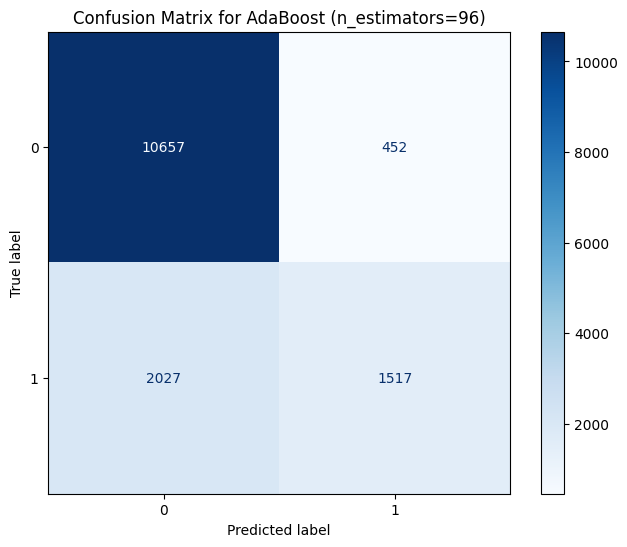

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize a base estimator (Decision Tree is common for AdaBoost)
base_estimator = DecisionTreeClassifier(max_depth=1) # A shallow tree is often used

# Build AdaBoost Classifier with the best n_estimators found
best_adaboost_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=best_n_estimators, random_state=42)

# Train the model
best_adaboost_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_best = best_adaboost_clf.predict(X_test)

# Calculate the accuracy score
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"\nBest Accuracy Score achieved: {accuracy_best:.4f}")
print(f"Number of estimators for best score: {best_n_estimators}")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix:")
print(cm)

# Display the confusion matrix visually
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_adaboost_clf.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f'Confusion Matrix for AdaBoost (n_estimators={best_n_estimators})')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assuming the target column is named 'income' and it's binary (e.g., '>50K', '<=50K')
# If your target column has a different name, please modify 'target_column_name'
target_column_name = 'income_level'

if target_column_name in df.columns:
    # Separate features (X) and target (y)
    X = df.drop(columns=[target_column_name])
    y = df[target_column_name]

    # Encode the target variable if it's categorical
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
        print(f"Target variable classes: {le.classes_} mapped to {le.transform(le.classes_)}")

    # Handle categorical features in X using one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print(f"\nShape of X_train: {X_train.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of y_test: {y_test.shape}")
else:
    print(f"Error: Target column '{target_column_name}' not found in the dataset. Please adjust the 'target_column_name' variable.")


Shape of X_train: (34189, 6)
Shape of X_test: (14653, 6)
Shape of y_train: (34189,)
Shape of y_test: (14653,)


### Build and Evaluate AdaBoost Classifier

Now, we'll build an AdaBoost classifier with `n_estimators=10` and evaluate its prediction score.

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize a base estimator (Decision Tree is common for AdaBoost)
base_estimator = DecisionTreeClassifier(max_depth=1) # A shallow tree is often used

# Build AdaBoost Classifier with n_estimators=10
adaboost_clf_10 = AdaBoostClassifier(estimator=base_estimator, n_estimators=10, random_state=42)

# Train the model
adaboost_clf_10.fit(X_train, y_train)

# Make predictions on the test set
y_pred_10 = adaboost_clf_10.predict(X_test)

# Calculate the accuracy score
score_10 = accuracy_score(y_test, y_pred_10)

print(f"AdaBoost Classifier (n_estimators=10) Prediction Score: {score_10:.4f}")

AdaBoost Classifier (n_estimators=10) Prediction Score: 0.8277


### Fine-tune `n_estimators` to identify the best score

We will now iterate through different values of `n_estimators` to find the number of trees that yields the best prediction score for the AdaBoost classifier.


Best Prediction Score achieved: 0.8308
Number of estimators for best score: 96


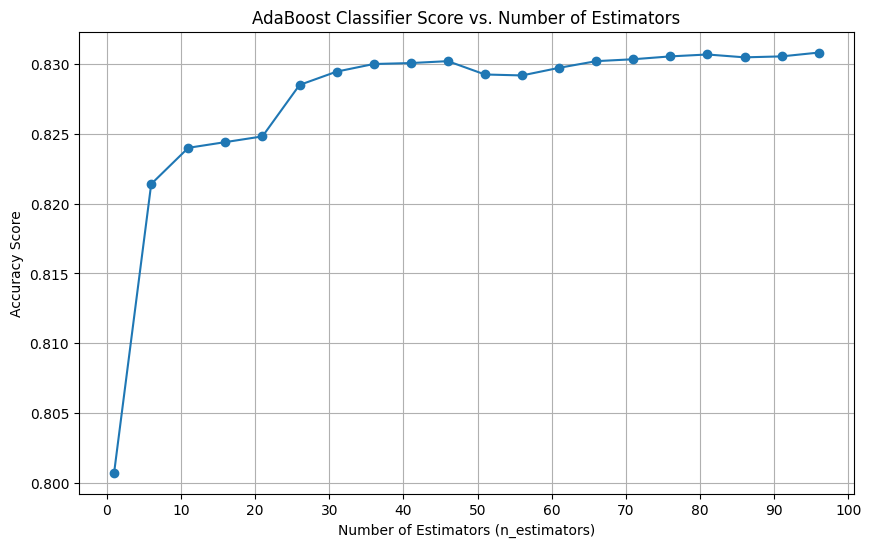

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define a range of n_estimators to test
estimator_range = range(1, 101, 5) # Test from 1 to 100 with step of 5

scores = []

for n in estimator_range:
    adaboost_clf = AdaBoostClassifier(estimator=base_estimator, n_estimators=n, random_state=42)
    adaboost_clf.fit(X_train, y_train)
    y_pred = adaboost_clf.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# Find the best score and corresponding n_estimators
best_score = np.max(scores)
best_n_estimators = estimator_range[np.argmax(scores)]

print(f"\nBest Prediction Score achieved: {best_score:.4f}")
print(f"Number of estimators for best score: {best_n_estimators}")

# Plot the results
fig = plt.figure(figsize=(10, 6))
plt.plot(estimator_range, scores, marker='o', linestyle='-')
plt.title('AdaBoost Classifier Score vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.xticks(np.arange(0, 101, 10))
plt.show()